*Scripts to read in the output of 3dROIstats for the activation masks identified by contrasts of main effects of task condition (go correct vs no-go correct), sleep measure, and their interactions*

In [1]:
# Load required packages
library(stringr)
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(broom)
library(purrr)
library(openxlsx)

library(lme4)
library(lmerTest)
library(broom.mixed)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:base’:

    %||%


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack



Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




Main effet of task conditions first

In [2]:
# ===============================
# User parameters
# ===============================

# analysis directory
# outDir <- "/Volumes/Yorick/Duraccio_RAD/derivatives/grp-2025-12-04"
outDir <- "/Users/bkirwan/projects/Duraccio_RAD/derivatives/grp-2025-12-04"
  
#change depending on which mask you want:

## Main effect of task:
# Input filename
filename <- "MVM1_ME_task_p.01_k55_a.05_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "L. Inf. Occipital/Temporal",
  "R. Inf. Occipital/Temporal",
  "R. Pre/Post Central Gyrus",
  "B. ACC",
  "L. DLPFC",
  "R. Anterior Insula/Striatum/Amygdala",
  "R. DLPFC",
  "R. Inf. Parietal Lobule",
  "R. SMA",
  "L. Middle Temporal Gyrus",
  "L. Anterior Insula"
)

# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)



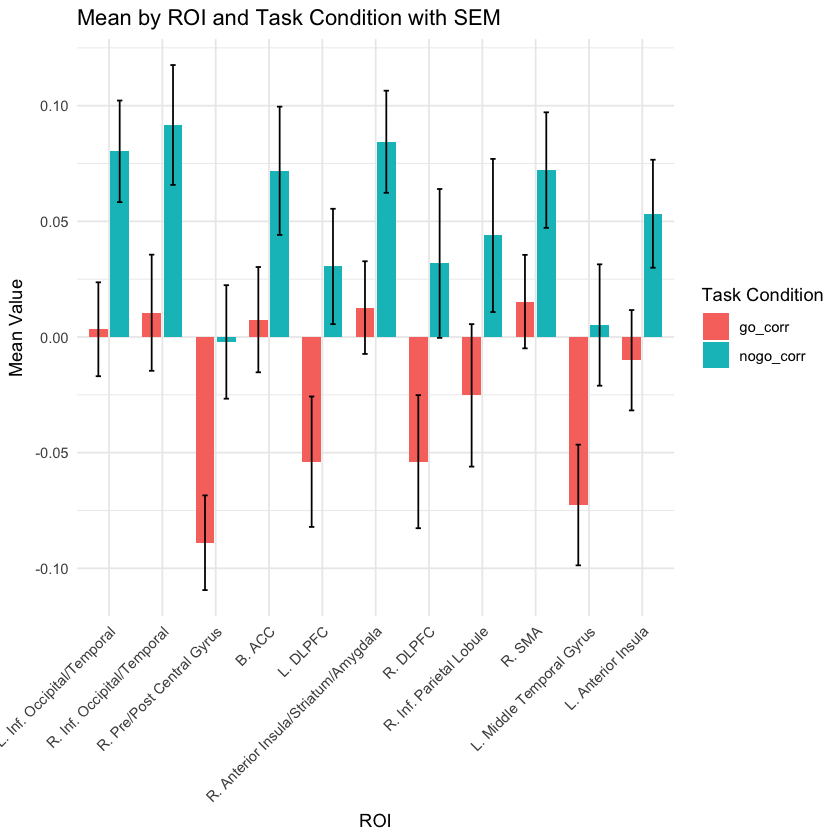

In [3]:

# ===============================
# Plot Stuff
# ===============================
# Compute mean and SEM by ROI and task_condition
summary_df <- df_long %>%
  filter(!is.na(task_condition)) %>%    # exclude rows without task_condition
  group_by(ROI, task_condition) %>%
  summarise(
    mean_value = mean(value, na.rm = TRUE),
    sem = sd(value, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Plot bar graph with error bars
ggplot(summary_df, aes(x = ROI, y = mean_value, fill = task_condition)) +
  geom_col(position = position_dodge(0.8), width = 0.7) +
  geom_errorbar(aes(ymin = mean_value - sem, ymax = mean_value + sem),
                width = 0.2, position = position_dodge(0.8)) +
  labs(
    x = "ROI",
    y = "Mean Value",
    fill = "Task Condition",
    title = "Mean by ROI and Task Condition with SEM"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 6, height = 4)



In [4]:

# ===============================
# Stats Stuff
# ===============================

# Paired t-tests go_corr vs nogo_corr within each ROI
ttest_results <- df_long %>%
  select(subjID, ROI, task_condition, value) %>%
  pivot_wider(names_from = task_condition, values_from = value) %>%
  group_by(ROI) %>%
  summarise(
    test = list(t.test(go_corr, nogo_corr, paired = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(stats = map(test, tidy)) %>%
  unnest(stats) %>%
  # note: "parameter" = degrees of freedom from t.test()
  select(ROI, estimate, statistic, parameter, p.value, conf.low, conf.high)

print(ttest_results)




# A tibble: 11 × 7
   ROI                   estimate statistic parameter p.value conf.low conf.high
   <fct>                    <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
 1 L. Inf. Occipital/Te…  -0.0769     -5.62        40 1.62e-6  -0.105    -0.0493
 2 R. Inf. Occipital/Te…  -0.0812     -6.33        40 1.62e-7  -0.107    -0.0553
 3 R. Pre/Post Central …  -0.0868     -6.67        40 5.42e-8  -0.113    -0.0605
 4 B. ACC                 -0.0644     -4.02        40 2.52e-4  -0.0967   -0.0320
 5 L. DLPFC               -0.0844     -5.15        40 7.24e-6  -0.118    -0.0513
 6 R. Anterior Insula/S…  -0.0717     -5.28        40 4.90e-6  -0.0992   -0.0442
 7 R. DLPFC               -0.0857     -5.24        40 5.52e-6  -0.119    -0.0526
 8 R. Inf. Parietal Lob…  -0.0691     -4.46        40 6.44e-5  -0.100    -0.0378
 9 R. SMA                 -0.0569     -4.56        40 4.80e-5  -0.0821   -0.0316
10 L. Middle Temporal G…  -0.0778     -4.80        40 2.23e-5  -0.111    -0.0450
11 L. Ant

Analysis 2: Main effect of DLMO (continuous)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 2 × 5
  ROI               r  p_value    beta r_squared
  <fct>         <dbl>    <dbl>   <dbl>     <dbl>
1 VMPFC         0.587 0.000133 0.00277     0.345
2 Retrosplenial 0.543 0.000517 0.00184     0.295


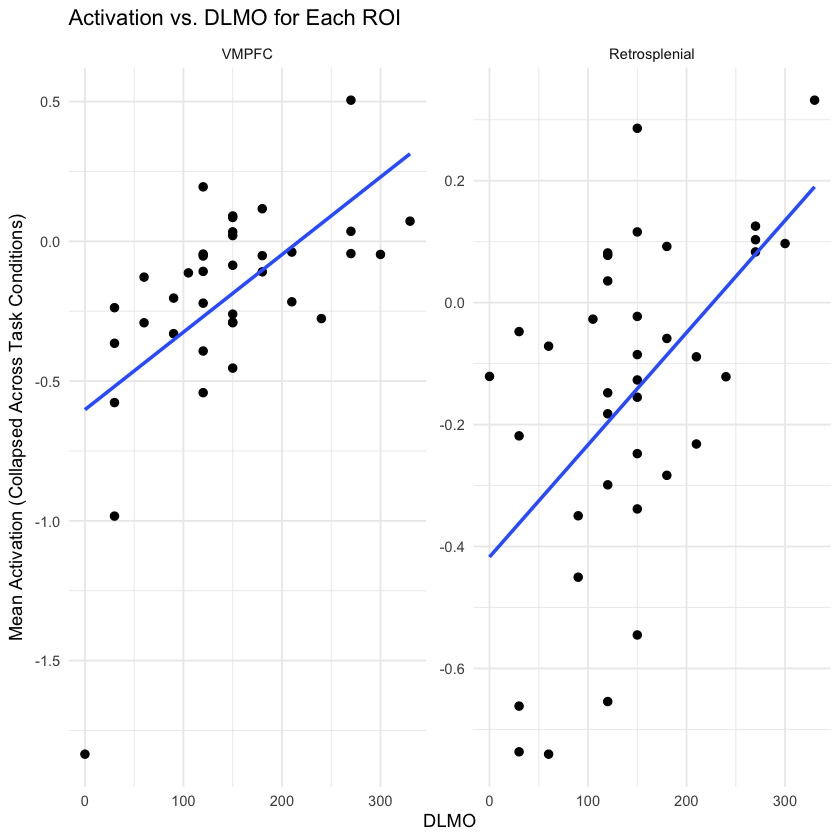

In [5]:
## Main effect of DLMO (continuous):
# Input filename
filename <- "MVM1_ME_dlmo_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "VMPFC",
  "Retrosplenial"
)


# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Read in subjects table with predictor variables
xlsinfile <- "/Users/bkirwan/projects/Duraccio_RAD/code/Subject_dataframe.xlsx"
subject_table <- read.xlsx(xlsinfile, sheet = 1)

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )

# ===============================
# Plot Stuff
# ===============================

df_collapsed <- df_long_joined %>%
  filter(!is.na(task_condition)) %>%        # keep usable rows
  filter(!is.na(DLMO)) %>%                  # remove subjects missing DLMO
  group_by(subjID, ROI) %>%                 # subject × ROI level
  summarise(
    mean_activation = mean(value, na.rm = TRUE),   # average gocorr + nogocorr
    DLMO = first(DLMO),                            # same per subject
    .groups = "drop"
  )

ggplot(df_collapsed, aes(x = DLMO, y = mean_activation)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ ROI, scales = "free_y") +
  labs(
    x = "DLMO",
    y = "Mean Activation (Collapsed Across Task Conditions)",
    title = "Activation vs. DLMO for Each ROI"
  ) +
  theme_minimal()

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 6, height = 4)

# model to characterize the relationship between DLMO and mean activation (collapsed across task condition) by ROI
results <- df_collapsed %>%
  group_by(ROI) %>%
  group_modify(~{
    # Fit linear model (activation ~ DLMO)
    model <- lm(mean_activation ~ DLMO, data = .x)
    model_summary <- summary(model)
    
    # Pearson correlation
    cor_test <- cor.test(.x$mean_activation, .x$DLMO)
    
    # Return a tibble with statistics
    tibble(
      r         = unname(cor_test$estimate),
      p_value   = cor_test$p.value,
      beta      = unname(coef(model)[2]),    # slope
      r_squared = model_summary$r.squared
    )
  }) %>%
  ungroup()

# View the results
print(results)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


ROI,term,estimate,std.error,statistic,p.value
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
R. Post. Operculum,(Intercept),-0.2772820428,0.0536885234,-5.164643,6.434204e-06
R. Post. Operculum,DLMO,0.0009158317,0.0003262607,2.807055,7.588275e-03
R. Post. Operculum,task_conditionnogo_corr,0.1619445953,0.0312569538,5.181074,9.276223e-06
R. Post. Operculum,DLMO:task_conditionnogo_corr,-0.0008273074,0.0001899459,-4.355490,1.103502e-04
L. Post. Operculum,(Intercept),-0.2030152366,0.0677110686,-2.998258,4.712881e-03
L. Post. Operculum,DLMO,0.0008363611,0.0004114745,2.032595,4.895598e-02
L. Post. Operculum,task_conditionnogo_corr,0.1151601061,0.0312395097,3.686361,7.653066e-04
L. Post. Operculum,DLMO:task_conditionnogo_corr,-0.0009168891,0.0001898399,-4.829802,2.679821e-05
L. Ant. Operculum,(Intercept),-0.1729474174,0.0702742572,-2.461035,1.812740e-02


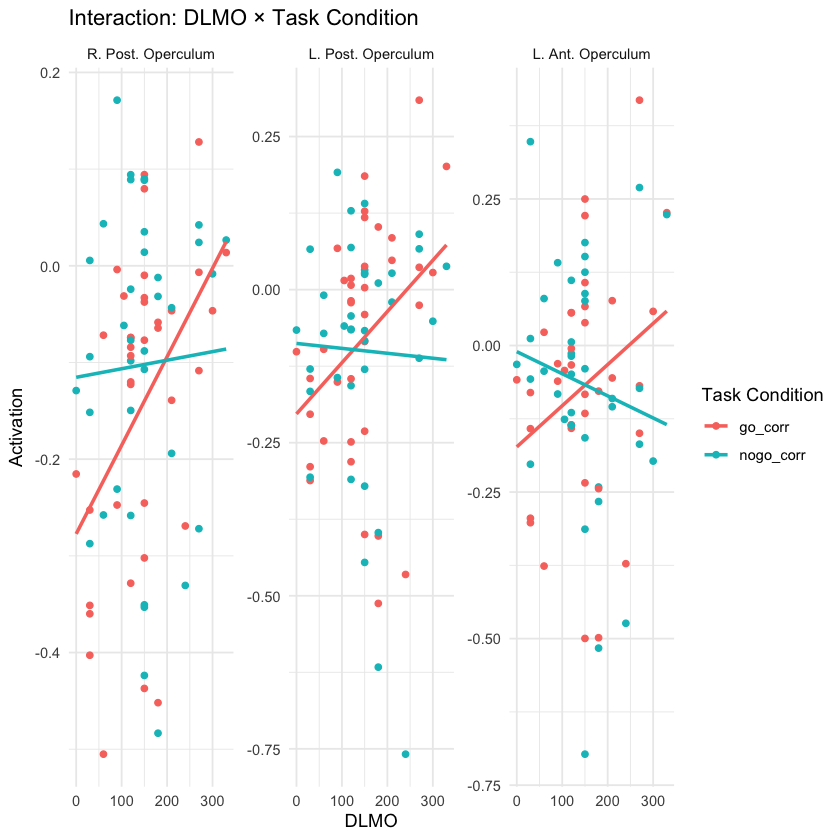

In [15]:
## DLMO x Task condition interaction (continuous):
# Input filename
filename <- "MVM1_Intx_dlmo_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "R. Post. Operculum",
  "L. Post. Operculum",
  "L. Ant. Operculum"
)


# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )

# ===============================
# Plot Stuff
# ===============================
df_clean <- df_long_joined %>%
  filter(!is.na(DLMO))

ggplot(df_clean, aes(x = DLMO, y = value, color = task_condition)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ ROI, scales = "free_y") +
  labs(
    x = "DLMO",
    y = "Activation",
    color = "Task Condition",
    title = "Interaction: DLMO × Task Condition"
  ) +
  theme_minimal()
#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 12, height = 4)

#model each ROI's data and pull out the interaction terms
results_by_roi <- df_clean %>%
  group_by(ROI) %>%
  group_modify(~{
    # lmerTest provides p-values
    model <- lmer(value ~ DLMO * task_condition + (1|subjID), data = .x)
    
    broom.mixed::tidy(model, effects = "fixed") %>%
      select(term, estimate, std.error, statistic, p.value)
  }) %>%
  ungroup()

# Filter significant predictors
results_sig <- results_by_roi %>%
  filter(p.value < 0.05)

results_sig

Main effect of social jet lag (SJL) continuous

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 3 × 5
  ROI                          r   p_value     beta r_squared
  <fct>                    <dbl>     <dbl>    <dbl>     <dbl>
1 L. Occipitoparietal      0.581 0.000161   0.00226     0.338
2 L. Amygdala/Ant. Insula -0.622 0.0000398 -0.00268     0.387
3 Midbrain                -0.646 0.0000160 -0.00410     0.417


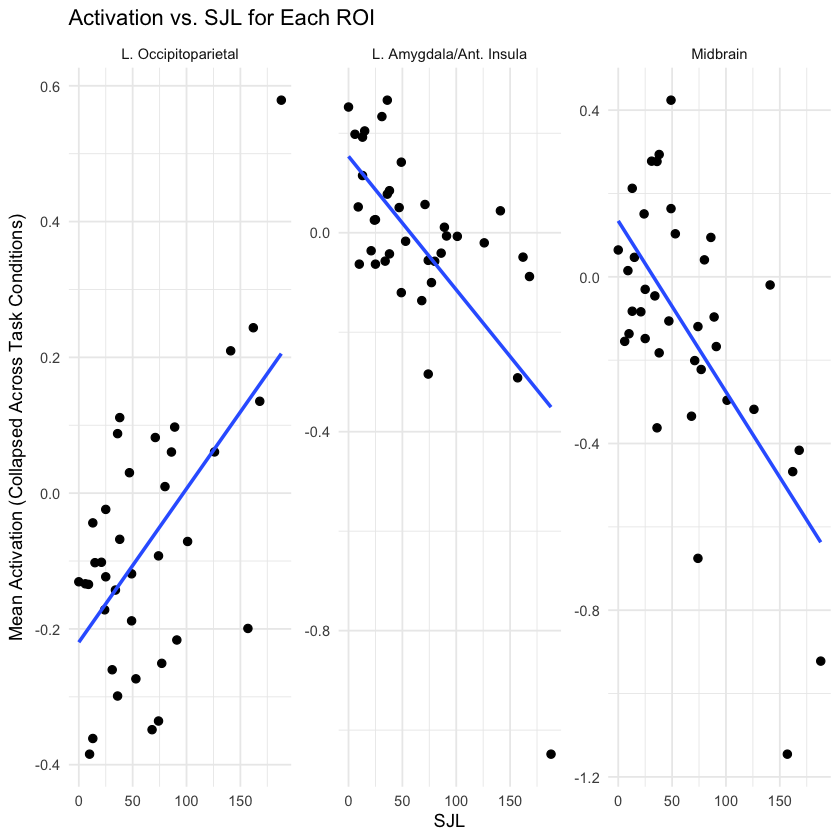

In [16]:
## Main effect of SJL (continuous):
# Input filename
filename <- "MVM1_ME_sjl_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "L. Occipitoparietal",
  "L. Amygdala/Ant. Insula",
  "Midbrain"    
)


# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Read in subjects table with predictor variables
xlsinfile <- "/Users/bkirwan/projects/Duraccio_RAD/code/Subject_dataframe.xlsx"
subject_table <- read.xlsx(xlsinfile, sheet = 1)

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )

# ===============================
# Plot Stuff
# ===============================

df_collapsed <- df_long_joined %>%
  filter(!is.na(task_condition)) %>%        # keep usable rows
  filter(!is.na(SJL)) %>%                  # remove subjects missing DLMO
  group_by(subjID, ROI) %>%                 # subject × ROI level
  summarise(
    mean_activation = mean(value, na.rm = TRUE),   # average gocorr + nogocorr
    SJL = first(SJL),                            # same per subject
    .groups = "drop"
  )

ggplot(df_collapsed, aes(x = SJL, y = mean_activation)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ ROI, scales = "free_y") +
  labs(
    x = "SJL",
    y = "Mean Activation (Collapsed Across Task Conditions)",
    title = "Activation vs. SJL for Each ROI"
  ) +
  theme_minimal()

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 12, height = 4)

# model to characterize the relationship between SJL and mean activation (collapsed across task condition) by ROI
results <- df_collapsed %>%
  group_by(ROI) %>%
  group_modify(~{
    # Fit linear model (activation ~ SJL)
    model <- lm(mean_activation ~ SJL, data = .x)
    model_summary <- summary(model)
    
    # Pearson correlation
    cor_test <- cor.test(.x$mean_activation, .x$SJL)
    
    # Return a tibble with statistics
    tibble(
      r         = unname(cor_test$estimate),
      p_value   = cor_test$p.value,
      beta      = unname(coef(model)[2]),    # slope
      r_squared = model_summary$r.squared
    )
  }) %>%
  ungroup()

# View the results
print(results)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


# A tibble: 1 × 5
  ROI                   r    p_value     beta r_squared
  <fct>             <dbl>      <dbl>    <dbl>     <dbl>
1 Ventral Striatum -0.666 0.00000514 -0.00501     0.443


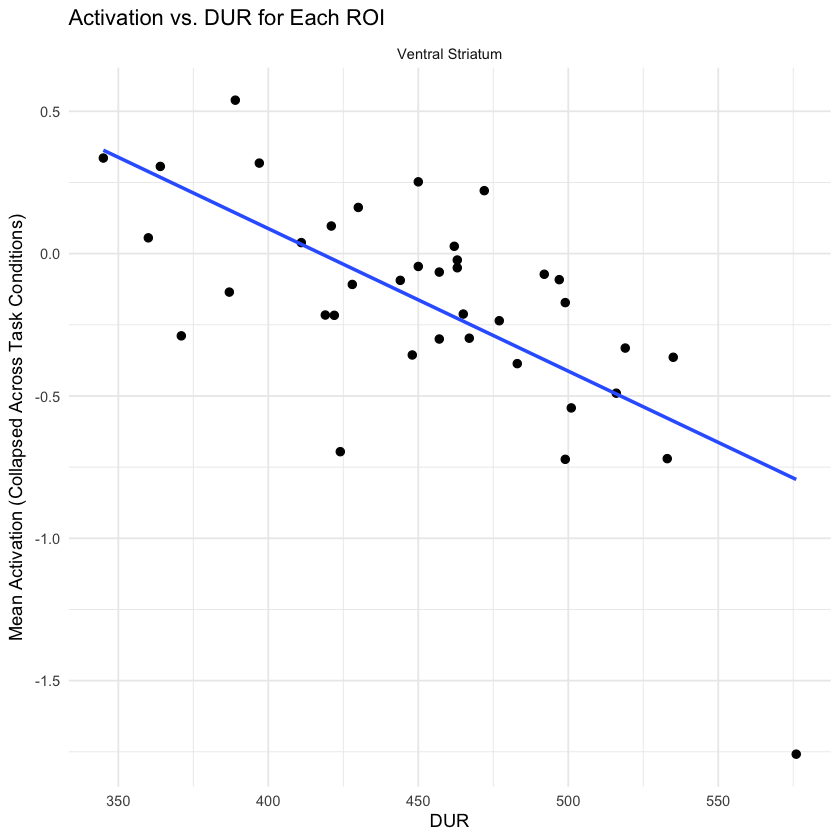

In [8]:
## Main effect of Duration (DUR) (continuous):
# Input filename
filename <- "ME_dura_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "Ventral Striatum"    
)


# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Read in subjects table with predictor variables
xlsinfile <- "/Users/bkirwan/projects/Duraccio_RAD/code/Subject_dataframe.xlsx"
subject_table <- read.xlsx(xlsinfile, sheet = 1)

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )


# ===============================
# Plot Stuff
# ===============================

df_collapsed <- df_long_joined %>%
  filter(!is.na(task_condition)) %>%        # keep usable rows
  filter(!is.na(DUR)) %>%                  # remove subjects missing DUR
  group_by(subjID, ROI) %>%                 # subject × ROI level
  summarise(
    mean_activation = mean(value, na.rm = TRUE),   # average gocorr + nogocorr
    DUR = first(DUR),                            # same per subject
    .groups = "drop"
  )

ggplot(df_collapsed, aes(x = DUR, y = mean_activation)) +
  geom_point(size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~ ROI, scales = "free_y") +
  labs(
    x = "DUR",
    y = "Mean Activation (Collapsed Across Task Conditions)",
    title = "Activation vs. DUR for Each ROI"
  ) +
  theme_minimal()

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 6, height = 4)

# model to characterize the relationship between SJL and mean activation (collapsed across task condition) by ROI
results <- df_collapsed %>%
  group_by(ROI) %>%
  group_modify(~{
    # Fit linear model (activation ~ DUR)
    model <- lm(mean_activation ~ DUR, data = .x)
    model_summary <- summary(model)
    
    # Pearson correlation
    cor_test <- cor.test(.x$mean_activation, .x$DUR)
    
    # Return a tibble with statistics
    tibble(
      r         = unname(cor_test$estimate),
      p_value   = cor_test$p.value,
      beta      = unname(coef(model)[2]),    # slope
      r_squared = model_summary$r.squared
    )
  }) %>%
  ungroup()

# View the results
print(results)

# A tibble: 1 × 7
# Rowwise: 
  ROI      mean_diff t_stat    df p_value  ci_low ci_high
  <fct>        <dbl>  <dbl> <dbl>   <dbl>   <dbl>   <dbl>
1 Midbrain     0.136   1.59  30.2   0.122 -0.0383   0.310


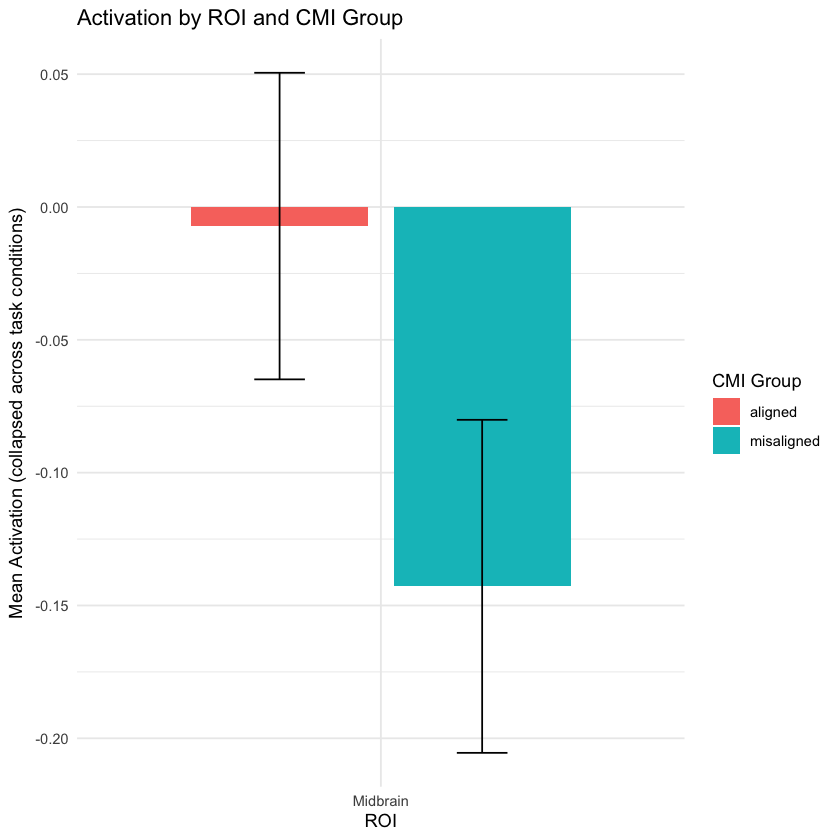

In [12]:
## Main effect of circadean misalignment (CMI) dichotomous:
# Input filename
filename <- "MVM1_ME_CMId_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "Midbrain"    
)

# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Read in subjects table with predictor variables
xlsinfile <- "/Users/bkirwan/projects/Duraccio_RAD/code/Subject_dataframe.xlsx"
subject_table <- read.xlsx(xlsinfile, sheet = 1)

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )
#head(df_long_joined)

# ===============================
# Plot Stuff
# ===============================
df_plot <- df_long_joined %>%
  filter(!is.na(CMI_Dich)) %>%   # keep only subjects with CMI group
  group_by(subjID, CMI_Dich, ROI) %>%
  summarise(mean_activation = mean(value, na.rm = TRUE),
            .groups = "drop")

# Plot: bar graph with error bars
ggplot(df_plot, aes(x = ROI, y = mean_activation, fill = CMI_Dich)) +
  stat_summary(fun = mean, geom = "col", position = position_dodge(0.8), width = 0.7) +
  stat_summary(fun.data = mean_se, geom = "errorbar",
               position = position_dodge(0.8), width = 0.2) +
  labs(
    x = "ROI",
    y = "Mean Activation (collapsed across task conditions)",
    fill = "CMI Group",
    title = "Activation by ROI and CMI Group"
  ) +
  theme_minimal() 

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 6, height = 4)

# ===============================
# Post-hoc between-groups comparisons
# ===============================

posthoc_results <- df_plot %>%
  group_by(ROI) %>%
  summarise(
    t_test = list(t.test(mean_activation ~ CMI_Dich, data = pick(everything()))),
    .groups = "drop"
  ) %>%
  rowwise() %>%
  mutate(
    # Mean difference: group1 - group2
    mean_diff = t_test$estimate[1] - t_test$estimate[2],
    t_stat = t_test$statistic,
    df = t_test$parameter,
    p_value = t_test$p.value,
    ci_low = t_test$conf.int[1],
    ci_high = t_test$conf.int[2]
  ) %>%
  select(ROI, mean_diff, t_stat, df, p_value, ci_low, ci_high)
print(posthoc_results)


# A tibble: 2 × 7
# Rowwise: 
  ROI         mean_diff t_stat    df  p_value ci_low ci_high
  <fct>           <dbl>  <dbl> <dbl>    <dbl>  <dbl>   <dbl>
1 Midbrain        0.314   4.36  22.8 0.000231 0.165    0.464
2 L. Amygdala     0.209   3.74  23.8 0.00103  0.0936   0.325


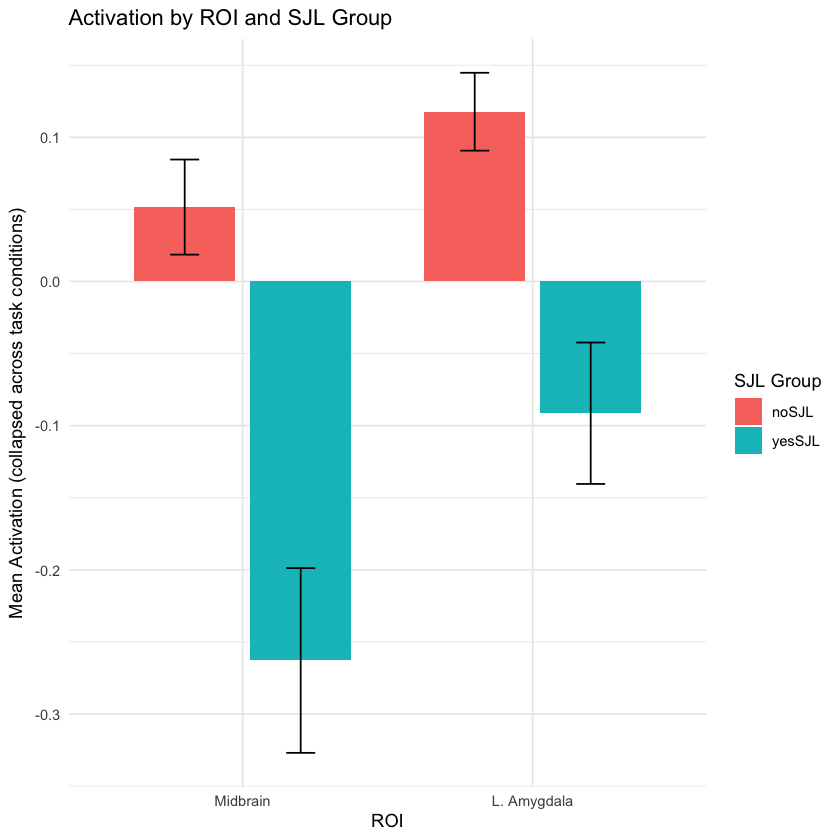

In [13]:
## Main effect of social jetlag (SJL) dichotomous:
# Input filename
filename <- "ME_sjld_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "Midbrain",
  "L. Amygdala"
)

# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Read in subjects table with predictor variables
xlsinfile <- "/Users/bkirwan/projects/Duraccio_RAD/code/Subject_dataframe.xlsx"
subject_table <- read.xlsx(xlsinfile, sheet = 1)

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )
#head(df_long_joined)

# ===============================
# Plot Stuff
# ===============================
df_plot <- df_long_joined %>%
  filter(!is.na(SJL_Dich)) %>%   # keep only subjects with SJL_Dich group
  group_by(subjID, SJL_Dich, ROI) %>%
  summarise(mean_activation = mean(value, na.rm = TRUE),
            .groups = "drop")

# Plot: bar graph with error bars
ggplot(df_plot, aes(x = ROI, y = mean_activation, fill = SJL_Dich)) +
  stat_summary(fun = mean, geom = "col", position = position_dodge(0.8), width = 0.7) +
  stat_summary(fun.data = mean_se, geom = "errorbar",
               position = position_dodge(0.8), width = 0.2) +
  labs(
    x = "ROI",
    y = "Mean Activation (collapsed across task conditions)",
    fill = "SJL Group",
    title = "Activation by ROI and SJL Group"
  ) +
  theme_minimal() 

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 6, height = 4)

# ===============================
# Post-hoc between-groups comparisons
# ===============================

posthoc_results <- df_plot %>%
  group_by(ROI) %>%
  summarise(
    t_test = list(t.test(mean_activation ~ SJL_Dich, data = pick(everything()))),
    .groups = "drop"
  ) %>%
  rowwise() %>%
  mutate(
    # Mean difference: group1 - group2
    mean_diff = t_test$estimate[1] - t_test$estimate[2],
    t_stat = t_test$statistic,
    df = t_test$parameter,
    p_value = t_test$p.value,
    ci_low = t_test$conf.int[1],
    ci_high = t_test$conf.int[2]
  ) %>%
  select(ROI, mean_diff, t_stat, df, p_value, ci_low, ci_high)
print(posthoc_results)


# A tibble: 7 × 7
# Rowwise: 
  ROI                      mean_diff t_stat    df   p_value ci_low ci_high
  <fct>                        <dbl>  <dbl> <dbl>     <dbl>  <dbl>   <dbl>
1 L. Amyg./Striatum/Insula    -0.213  -4.43  12.1 0.000799  -0.318 -0.108 
2 R. Striatum/Insula          -0.200  -5.66  18.5 0.0000206 -0.273 -0.126 
3 L. Inf. Frontal             -0.347  -3.80  12.8 0.00228   -0.544 -0.149 
4 R. Inf. Frontal             -0.447  -4.31  16.2 0.000531  -0.668 -0.227 
5 SMA                         -0.415  -3.38  12.4 0.00527   -0.682 -0.148 
6 L. Middle Temporal          -0.271  -3.27  12.6 0.00625   -0.450 -0.0915
7 ACC                         -0.222  -3.03  13.3 0.00953   -0.381 -0.0640


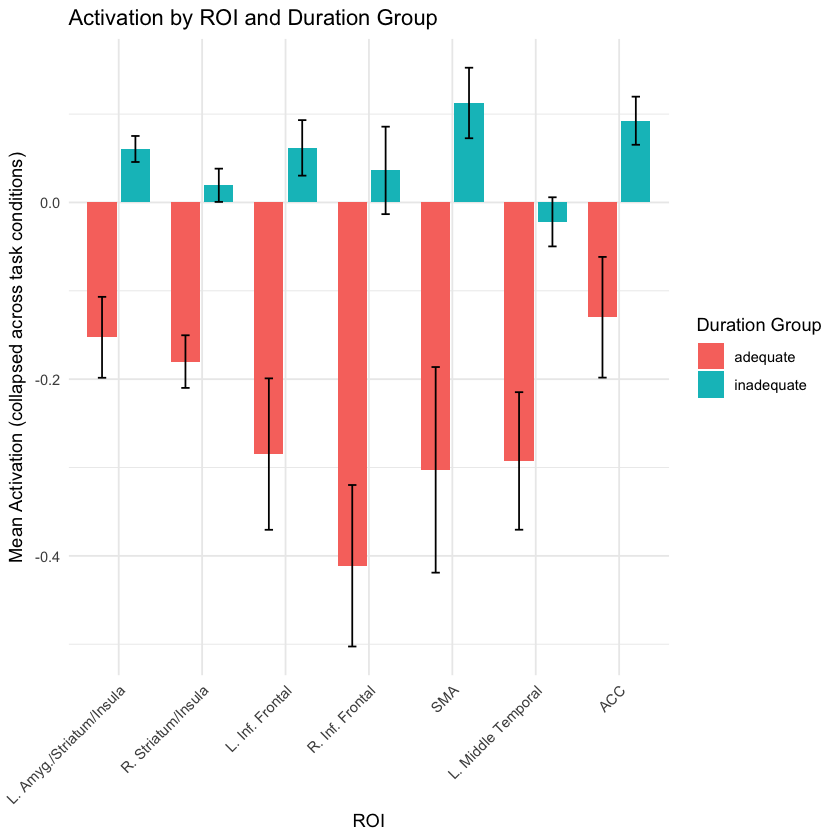

In [17]:
## Main effect of sleep duration (Dura) dichotomous:
# Input filename
filename <- "ME_durad_mask+tlrc.txt"
#ROI names
roi_names <- c(
  "L. Amyg./Striatum/Insula",
  "R. Striatum/Insula",
  "L. Inf. Frontal",
  "R. Inf. Frontal",
  "SMA",
  "L. Middle Temporal",
  "ACC"
)

# ===============================
# Read activation data via function read_roistats_ouput.R
# ===============================
# Read all lines
infile <- paste0(outDir,"/",filename)
# load and call the read_roistats_output function
source("/Users/bkirwan/projects/Duraccio_RAD/code/read_roistats_ouput.R")
df_long <- read_roistats_ouput(infile, roi_names)

# ===============================
# Read in sleep variables, select subjects for just this analysis
# ===============================

# Read in subjects table with predictor variables
xlsinfile <- "/Users/bkirwan/projects/Duraccio_RAD/code/Subject_dataframe.xlsx"
subject_table <- read.xlsx(xlsinfile, sheet = 1)

# Join with subject predictors
df_long_joined <- df_long %>%
  left_join(subject_table, by = c("subjID" = "Subj"))

# the dichotomous variables are all factors
df_long_joined <- df_long_joined %>%
  mutate(
    DLMO_Dich = recode_factor(DLMO_Dich, `1` = "early", `2` = "late"),
    CMI_Dich  = recode_factor(CMI_Dich, `1` = "aligned", `2` = "misaligned"),
    SJL_Dich  = recode_factor(SJL_Dich, `1` = "noSJL", `2` = "yesSJL"),
    Dur_Dich = recode_factor(Dur_Dich, `1` = "adequate", `2` = "inadequate")
  )
#head(df_long_joined)

# ===============================
# Plot Stuff
# ===============================
df_plot <- df_long_joined %>%
  filter(!is.na(Dur_Dich)) %>%   # keep only subjects with Dur_Dich group
  group_by(subjID, Dur_Dich, ROI) %>%
  summarise(mean_activation = mean(value, na.rm = TRUE),
            .groups = "drop")

# Plot: bar graph with error bars
ggplot(df_plot, aes(x = ROI, y = mean_activation, fill = Dur_Dich)) +
  stat_summary(fun = mean, geom = "col", position = position_dodge(0.8), width = 0.7) +
  stat_summary(fun.data = mean_se, geom = "errorbar",
               position = position_dodge(0.8), width = 0.2) +
  labs(
    x = "ROI",
    y = "Mean Activation (collapsed across task conditions)",
    fill = "Duration Group",
    title = "Activation by ROI and Duration Group"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

#save figure
filename_pdf <- sub("\\.txt$", ".pdf", infile)

ggsave(filename_pdf, plot = last_plot(), width = 6, height = 4)

# ===============================
# Post-hoc between-groups comparisons
# ===============================

posthoc_results <- df_plot %>%
  group_by(ROI) %>%
  summarise(
    t_test = list(t.test(mean_activation ~ Dur_Dich, data = pick(everything()))),
    .groups = "drop"
  ) %>%
  rowwise() %>%
  mutate(
    # Mean difference: group1 - group2
    mean_diff = t_test$estimate[1] - t_test$estimate[2],
    t_stat = t_test$statistic,
    df = t_test$parameter,
    p_value = t_test$p.value,
    ci_low = t_test$conf.int[1],
    ci_high = t_test$conf.int[2]
  ) %>%
  select(ROI, mean_diff, t_stat, df, p_value, ci_low, ci_high)
print(posthoc_results)
